In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
from google.colab import files
uploaded = files.upload()

Saving warehouse_workforce_dataset_january_2025 - History Worker.csv to warehouse_workforce_dataset_january_2025 - History Worker.csv


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("/content/warehouse_workforce_dataset_january_2025 - History Worker.csv")
df.head()

,Tanggal,Hari,Barang_Masuk_KG,Worker_Aktual,Vendor_Aktif,Vendor A,Vendor B,Vendor C,Vendor D,Vendor E,Vendor F
0,01/01/2025,Rabu,3200,36,6,6,6,6,6,6,6
1,02/01/2025,Kamis,4100,42,6,7,7,7,7,7,7
2,03/01/2025,Jumat,5600,42,6,7,7,7,7,7,7
3,04/01/2025,Sabtu,7200,48,6,8,8,8,8,8,8
4,05/01/2025,Minggu,3000,36,6,6,6,6,6,6,6


In [8]:
df.info()
df.describe() # cke struktur data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Tanggal          31 non-null     object
 1   Hari             31 non-null     object
 2   Barang_Masuk_KG  31 non-null     int64 
 3   Worker_Aktual    31 non-null     int64 
 4   Vendor_Aktif     31 non-null     int64 
 5   Vendor A         31 non-null     int64 
 6   Vendor B         31 non-null     int64 
 7   Vendor C         31 non-null     int64 
 8   Vendor D         31 non-null     int64 
 9   Vendor E         31 non-null     int64 
 10  Vendor F         31 non-null     int64 
dtypes: int64(9), object(2)
memory usage: 2.8+ KB


,Barang_Masuk_KG,Worker_Aktual,Vendor_Aktif,Vendor A,Vendor B,Vendor C,Vendor D,Vendor E,Vendor F
count,31.000000,31.000000,31.0,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000
mean,7593.548387,50.322581,6.0,8.387097,8.387097,8.387097,8.387097,8.387097,8.387097
std,3253.299400,10.238447,0.0,1.706408,1.706408,1.706408,1.706408,1.706408,1.706408
min,3000.000000,36.000000,6.0,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000
25%,4900.000000,42.000000,6.0,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000
50%,7200.000000,48.000000,6.0,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
75%,9850.000000,57.000000,6.0,9.500000,9.500000,9.500000,9.500000,9.500000,9.500000
max,14000.000000,72.000000,6.0,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000


In [9]:
df["Tanggal"] = pd.to_datetime(df["Tanggal"], dayfirst=True) # ubah tanggal

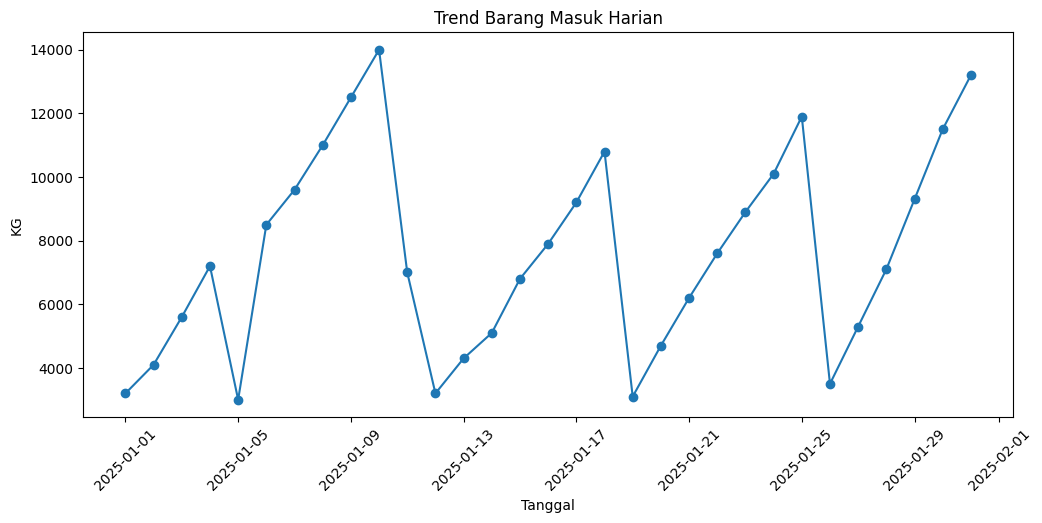

In [10]:
plt.figure(figsize=(12,5)) #Trend Barang masuk
plt.plot(df["Tanggal"], df["Barang_Masuk_KG"], marker='o')
plt.title("Trend Barang Masuk Harian")
plt.xlabel("Tanggal")
plt.ylabel("KG")
plt.xticks(rotation=45)
plt.show()

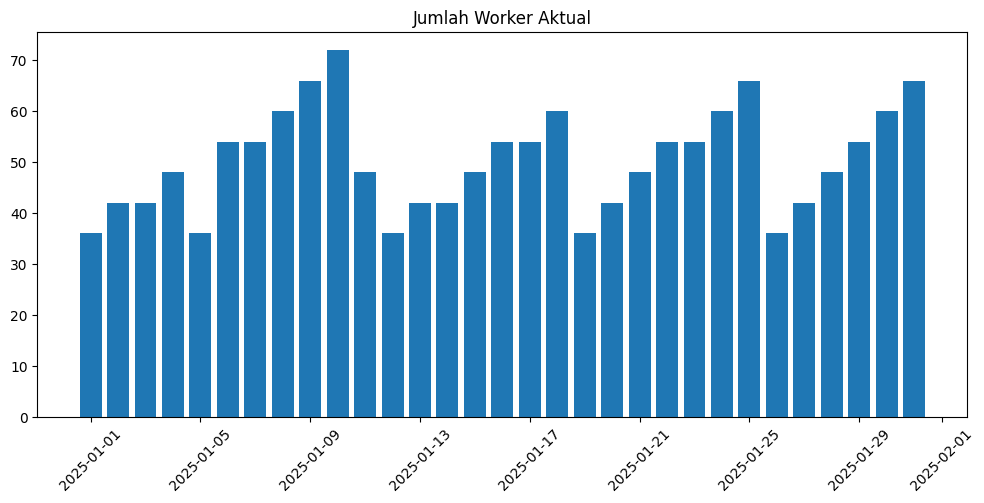

In [11]:
plt.figure(figsize=(12,5)) # worker aktual
plt.bar(df["Tanggal"], df["Worker_Aktual"])
plt.title("Jumlah Worker Aktual")
plt.xticks(rotation=45)
plt.show()

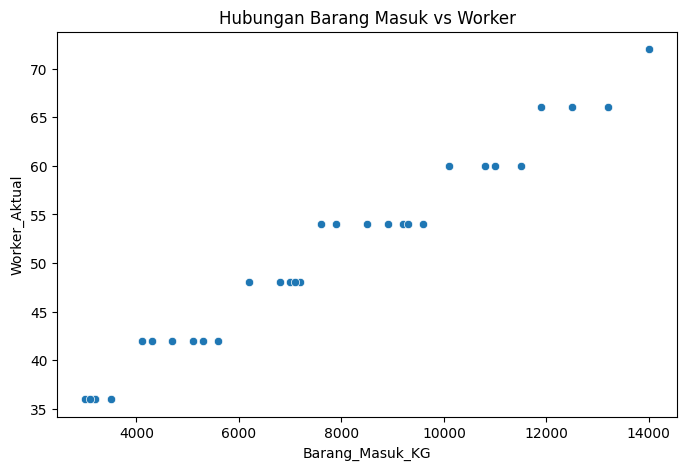

In [12]:
# korelasi antara barang dan pekerja
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Barang_Masuk_KG", y="Worker_Aktual")
plt.title("Hubungan Barang Masuk vs Worker")
plt.show()

In [13]:
# Prediksi menggunakan Linear Regression

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[["Barang_Masuk_KG"]]
y = df["Worker_Aktual"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [14]:
prediksi = model.predict([[10000]]) #prediksi minggu depan
print("Prediksi kebutuhan worker:", round(prediksi[0]))

Prediksi kebutuhan worker: 57


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [15]:
import numpy as np

# Simulasi barang masuk 30 hari ke depan
barang_prediksi = np.random.randint(3000, 14001, 30)

prediksi_worker = model.predict(barang_prediksi.reshape(-1,1))

future_df = pd.DataFrame({
    "Hari_Ke": range(1,31),
    "Prediksi_Barang_KG": barang_prediksi,
    "Prediksi_Worker": prediksi_worker.round().astype(int)
})

future_df.head(10)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,Hari_Ke,Prediksi_Barang_KG,Prediksi_Worker
0,1,8569,53
1,2,9840,57
2,3,3281,37
3,4,13019,67
4,5,10254,58
5,6,6377,46
6,7,8151,52
7,8,7213,49
8,9,9170,55
9,10,8587,53


In [16]:
from sklearn.metrics import r2_score # Akurasi Model

y_pred = model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.9321159357573628


In [17]:
future_df # Prediksi Untuk 1 bulan

,Hari_Ke,Prediksi_Barang_KG,Prediksi_Worker
0,1,8569,53
1,2,9840,57
2,3,3281,37
3,4,13019,67
4,5,10254,58
5,6,6377,46
6,7,8151,52
7,8,7213,49
8,9,9170,55
9,10,8587,53


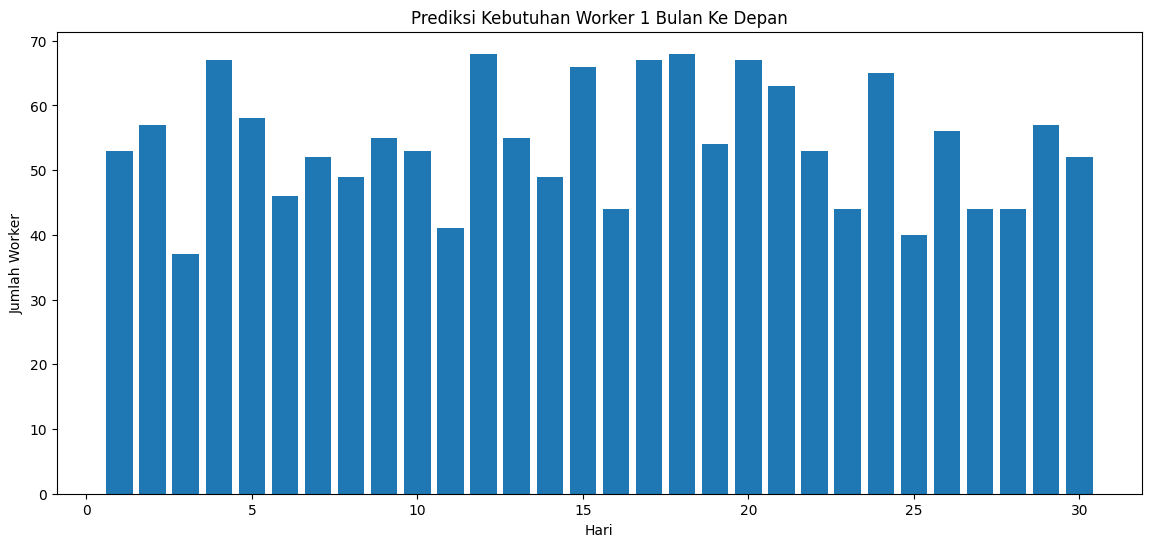

In [18]:
plt.figure(figsize=(14,6))
plt.bar(future_df["Hari_Ke"], future_df["Prediksi_Worker"])
plt.title("Prediksi Kebutuhan Worker 1 Bulan Ke Depan")
plt.xlabel("Hari")
plt.ylabel("Jumlah Worker")
plt.show()

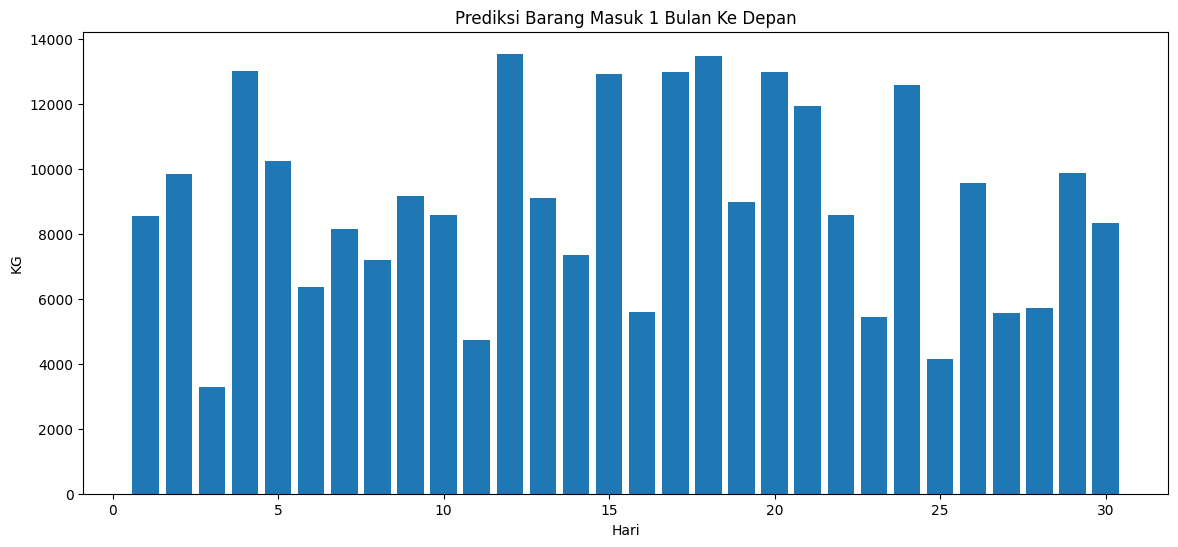

In [19]:
plt.figure(figsize=(14,6))
plt.bar(future_df["Hari_Ke"], future_df["Prediksi_Barang_KG"])
plt.title("Prediksi Barang Masuk 1 Bulan Ke Depan")
plt.xlabel("Hari")
plt.ylabel("KG")
plt.show()

In [20]:
print("Rata-rata worker:", round(future_df["Prediksi_Worker"].mean()))
print("Maksimum worker:", future_df["Prediksi_Worker"].max())
print("Minimum worker:", future_df["Prediksi_Worker"].min())

Rata-rata worker: 54
Maksimum worker: 68
Minimum worker: 37


**Final**

R2 Score : 0.932


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


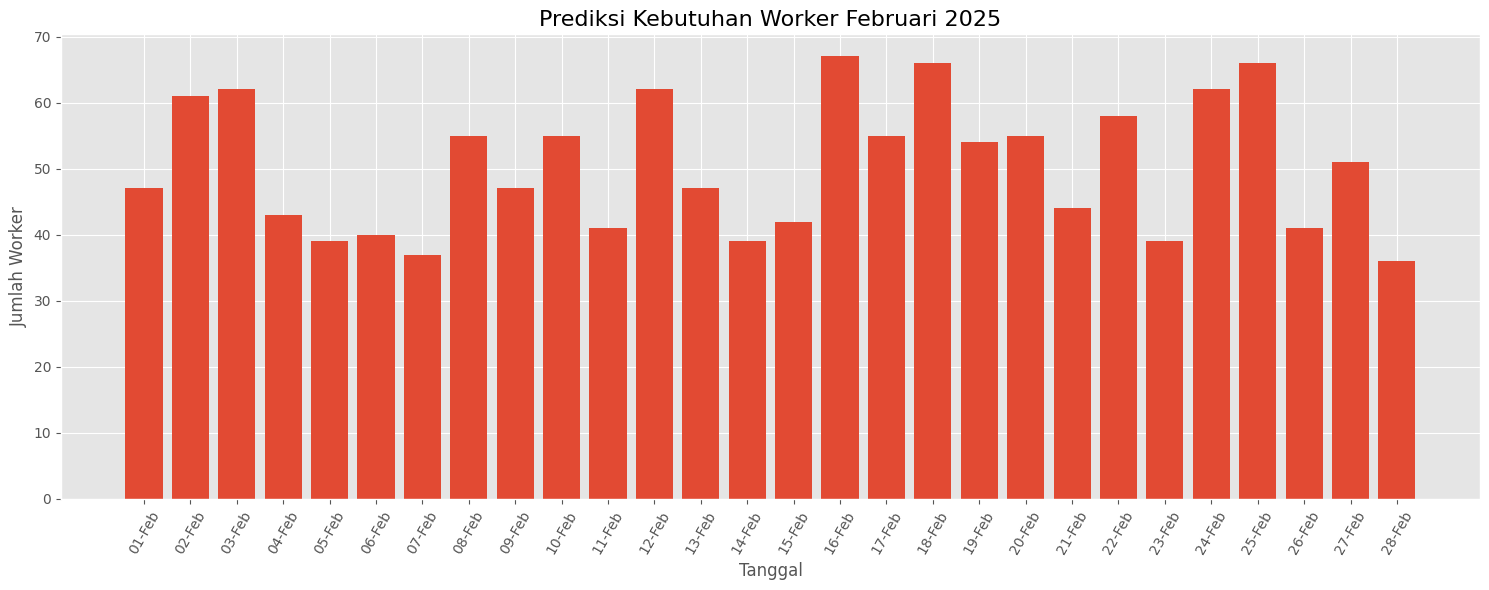

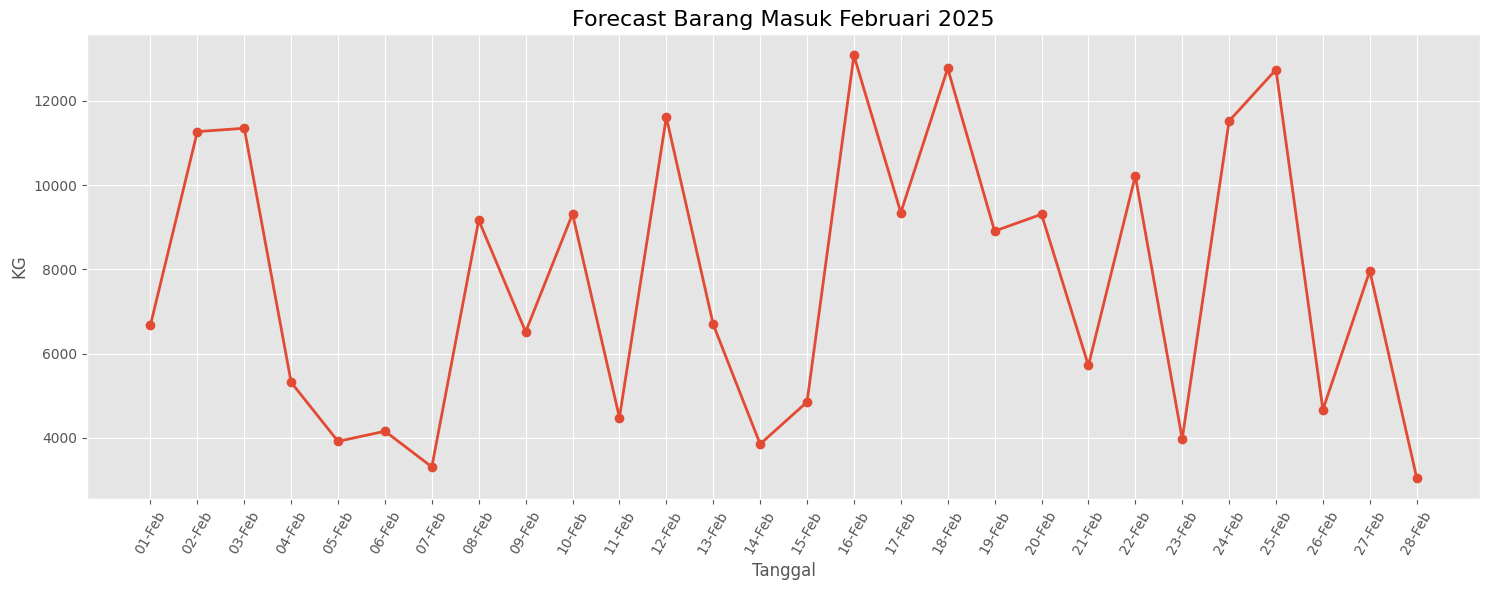

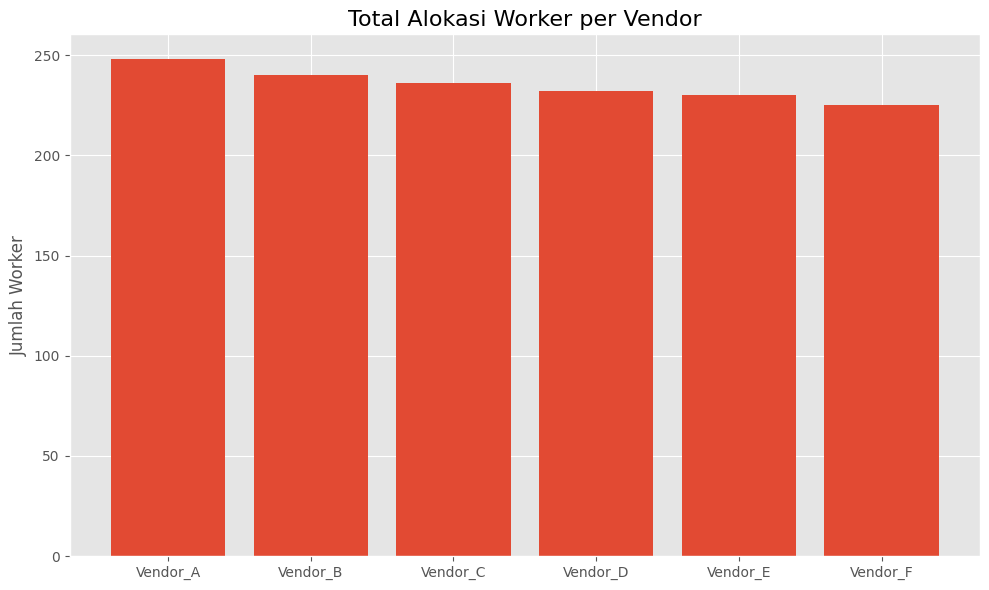

In [21]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


df = pd.read_csv("/content/warehouse_workforce_dataset_january_2025 - History Worker.csv")

df["Tanggal"] = pd.to_datetime(df["Tanggal"], dayfirst=True)


X = df[["Barang_Masuk_KG"]]
y = df["Worker_Aktual"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

# evaluasi model
y_pred = model.predict(X_test)
print("R2 Score :", round(r2_score(y_test, y_pred), 3))


# FORECAST TANGGAL 1 FEB - 28 FEB
tanggal_future = pd.date_range(
    start="2025-02-01",
    end="2025-02-28",
    freq="D"
)

# simulasi barang masuk
barang_future = np.random.randint(3000, 14001, len(tanggal_future))

# prediksi worker
worker_future = model.predict(
    barang_future.reshape(-1,1)
).round().astype(int)

# minimal worker = 36
worker_future = np.where(worker_future < 36, 36, worker_future)


# PEMBAGIAN 6 VENDOR
vendor_a = np.floor(worker_future / 6)
sisa = worker_future % 6

# distribusi rata buat vendor
vendor_list = []

for total in worker_future:
    base = total // 6
    rem = total % 6

    dist = [base]*6
    for i in range(rem):
        dist[i] += 1

    vendor_list.append(dist)

vendor_df = pd.DataFrame(
    vendor_list,
    columns=[
        "Vendor_A",
        "Vendor_B",
        "Vendor_C",
        "Vendor_D",
        "Vendor_E",
        "Vendor_F"
    ]
)


# DATAFRAME FINAL
future_df = pd.DataFrame({
    "Tanggal": tanggal_future,
    "Hari": tanggal_future.day_name(),
    "Prediksi_Barang_KG": barang_future,
    "Prediksi_Worker": worker_future
})

future_df = pd.concat([future_df, vendor_df], axis=1)

# tampilkan data
future_df.head(10)


plt.style.use("ggplot")


# Prediksi Worker Februari
plt.figure(figsize=(15,6))
plt.bar(
    future_df["Tanggal"].dt.strftime("%d-%b"),
    future_df["Prediksi_Worker"]
)

plt.title("Prediksi Kebutuhan Worker Februari 2025", fontsize=16)
plt.xlabel("Tanggal")
plt.ylabel("Jumlah Worker")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


# chart Prediksi Barang Masuk
plt.figure(figsize=(15,6))
plt.plot(
    future_df["Tanggal"].dt.strftime("%d-%b"),
    future_df["Prediksi_Barang_KG"],
    marker="o",
    linewidth=2
)

plt.title("Forecast Barang Masuk Februari 2025", fontsize=16)
plt.xlabel("Tanggal")
plt.ylabel("KG")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


# chart alokasi vendor

vendor_total = future_df[
    ["Vendor_A","Vendor_B","Vendor_C",
     "Vendor_D","Vendor_E","Vendor_F"]
].sum()

plt.figure(figsize=(10,6))
plt.bar(vendor_total.index, vendor_total.values)

plt.title("Total Alokasi Worker per Vendor", fontsize=16)
plt.ylabel("Jumlah Worker")
plt.tight_layout()
plt.show()


In [22]:
future_df.to_excel(
    "forecast_workforce_february_2025.xlsx",
    index=False
)

print("File berhasil dibuat:")
print("forecast_workforce_february_2025.xlsx")

File berhasil dibuat:
forecast_workforce_february_2025.xlsx



# HASIL PREDIKSI FEBRUARI 2025

Berdasarkan hasil forecasting menggunakan model Linear Regression, kebutuhan tenaga kerja outsourcing selama bulan Februari 2025 diperkirakan berada pada kisaran 36 hingga 72 pekerja per hari.
#
Dengan rata-rata kebutuhan sekitar 54 pekerja per hari,tergantung jumlah barang masuk harian. Jika volume barang rendah (sekitar 3.000 KG), maka kebutuhan minimum adalah 36 pekerja.
#
Jika volume barang tinggi (mendekati 14.000 KG), maka kebutuhan dapat meningkat hingga 72 pekerja. Sehingga total kebutuhan pekerja selama Februari 2025 dapat disiapkan secara fleksibel oleh 6 vendor outsourcing sesuai prediksi harian sistem.